In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

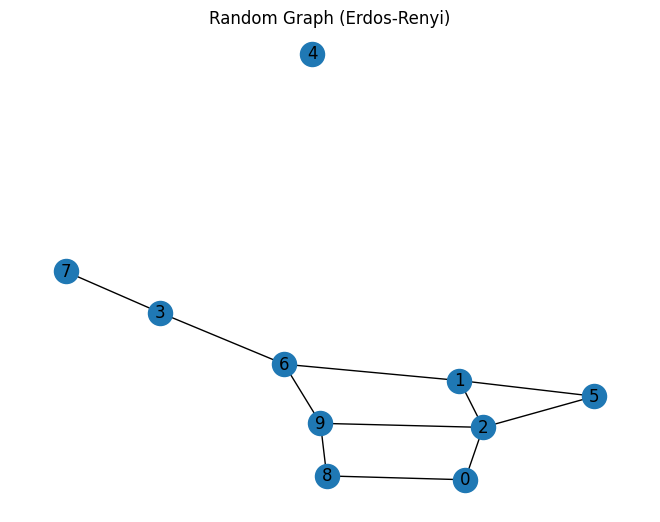

In [ ]:
G = nx.erdos_renyi_graph(n=10, p=0.2, seed=42)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.title('Random Graph (Erdos-Renyi)')
plt.show()

In [ ]:
def bfs(graph, start):
    visited = [False] * len(graph)
    queue = [start]
    visited[start] = True

    i = 0
    while i < len(queue):
        node = queue[i]
        print(node, end=" ")
        i += 1

        for neighbor in graph[node]:
            if visited[neighbor] == False:
                visited[neighbor] = True
                queue.append(neighbor)

In [ ]:
bfs(G,0)

0 2 8 1 5 9 6 3 7 

In [ ]:
# Floyd-Warshall
n = 10
INF = 999

dist = [[INF] * n for _ in range(n)]

for i in range(n):
    dist[i][i] = 0

for u, v in G.edges():
    dist[u][v] = 1
    dist[v][u] = 1

for k in range(n):
    for i in range(n):
        for j in range(n):
            if dist[i][k] + dist[k][j] < dist[i][j]:
                dist[i][j] = dist[i][k] + dist[k][j]

print("Shortest distance matrix:")
for i in range(n):
    print(dist[i])

Shortest distance matrix:
[0, 2, 1, 4, 999, 2, 3, 5, 1, 2]
[2, 0, 1, 2, 999, 1, 1, 3, 3, 2]
[1, 1, 0, 3, 999, 1, 2, 4, 2, 1]
[4, 2, 3, 0, 999, 3, 1, 1, 3, 2]
[999, 999, 999, 999, 0, 999, 999, 999, 999, 999]
[2, 1, 1, 3, 999, 0, 2, 4, 3, 2]
[3, 1, 2, 1, 999, 2, 0, 2, 2, 1]
[5, 3, 4, 1, 999, 4, 2, 0, 4, 3]
[1, 3, 2, 3, 999, 3, 2, 4, 0, 1]
[2, 2, 1, 2, 999, 2, 1, 3, 1, 0]


In [ ]:
# Johnson's Algorithm

n = 10
INF = 999

edges = []
for u, v in G.edges():
    edges.append((u, v, 1))
    edges.append((v, u, 1))

# Bellman-Ford
h = [0] * n
for _ in range(n - 1):
    for u, v, w in edges:
        if h[u] + w < h[v]:
            h[v] = h[u] + w

# Dijkstra from every node
for s in range(n):
    dist = [INF] * n
    used = [False] * n
    dist[s] = 0

    for _ in range(n):
        u = -1
        for i in range(n):
            if not used[i] and (u == -1 or dist[i] < dist[u]):
                u = i

        if u == -1:
            break

        used[u] = True

        for a, b, w in edges:
            if a == u and dist[b] > dist[a] + w:
                dist[b] = dist[a] + w

    print(s, ":", dist)

0 : [0, 2, 1, 4, 999, 2, 3, 5, 1, 2]
1 : [2, 0, 1, 2, 999, 1, 1, 3, 3, 2]
2 : [1, 1, 0, 3, 999, 1, 2, 4, 2, 1]
3 : [4, 2, 3, 0, 999, 3, 1, 1, 3, 2]
4 : [999, 999, 999, 999, 0, 999, 999, 999, 999, 999]
5 : [2, 1, 1, 3, 999, 0, 2, 4, 3, 2]
6 : [3, 1, 2, 1, 999, 2, 0, 2, 2, 1]
7 : [5, 3, 4, 1, 999, 4, 2, 0, 4, 3]
8 : [1, 3, 2, 3, 999, 3, 2, 4, 0, 1]
9 : [2, 2, 1, 2, 999, 2, 1, 3, 1, 0]


In [ ]:
# Connectivity Check

n = 10
visited = [False] * n
queue = [0]
visited[0] = True

i = 0
while i < len(queue):
    u = queue[i]
    i += 1

    for v in G[u]:
        if not visited[v]:
            visited[v] = True
            queue.append(v)

if all(visited):
    print("Graph is connected")
else:
    print("Graph is not connected")

Graph is not connected
